<a href="https://colab.research.google.com/github/aadvikk/flight_operations_delay_analysis/blob/main/flight_operations_delay_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flight Delay & Operational Performance Analysis

## Project Objective

In this project, flight operations data is analyzed using Python (Pandas) to understand flight delays, operational patterns, and performance trends. The goal is to identify delay trends, on-time performance, and operational insights through data analysis and visualizations.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
flights = pd.read_csv("Flight_Operations_Delay_500Rows.csv")

# Display first 5 rows
flights.head()

,Flight_ID,Airline,Origin_Airport,Destination_Airport,Scheduled_Departure,Actual_Departure,Delay_Minutes,Flight_Status,Flight_Duration_Minutes,Month,Day_of_Week,Departure_Hour
0,FL1000,Go First,BOM,DEL,2025-04-04 21:00,2025-04-04 21:38,38,Delayed,122,Apr,Friday,21
1,FL1001,Go First,BOM,PNQ,2025-01-30 16:00,2025-01-30 16:24,24,Delayed,211,Jan,Thursday,16
2,FL1002,IndiGo,BOM,BLR,2025-03-21 09:00,2025-03-21 09:42,42,Delayed,189,Mar,Friday,9
3,FL1003,Akasa Air,HYD,PNQ,2025-05-24 04:00,2025-05-24 05:01,61,Delayed,116,May,Saturday,4
4,FL1004,SpiceJet,DEL,AMD,2025-02-24 11:00,2025-02-24 11:22,22,Delayed,168,Feb,Monday,11


## Data Understanding

The dataset contains flight operation records including airlines, airports, departure timings, delay minutes, operational status, and scheduling information. The analysis focuses on identifying operational trends, delay behavior, and performance insights.


In [ ]:
# Dataset shape
print("Rows and Columns:", flights.shape)

# Column information
flights.info()

# Statistical summary
flights.describe()

Rows and Columns: (500, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Flight_ID                500 non-null    object
 1   Airline                  500 non-null    object
 2   Origin_Airport           500 non-null    object
 3   Destination_Airport      500 non-null    object
 4   Scheduled_Departure      500 non-null    object
 5   Actual_Departure         500 non-null    object
 6   Delay_Minutes            500 non-null    int64 
 7   Flight_Status            500 non-null    object
 8   Flight_Duration_Minutes  500 non-null    int64 
 9   Month                    500 non-null    object
 10  Day_of_Week              500 non-null    object
 11  Departure_Hour           500 non-null    int64 
dtypes: int64(3), object(9)
memory usage: 47.0+ KB


,Delay_Minutes,Flight_Duration_Minutes,Departure_Hour
count,500.000000,500.000000,500.000000
mean,27.736000,144.968000,11.882000
std,20.342417,45.765488,6.984672
min,0.000000,60.000000,0.000000
25%,11.000000,105.000000,6.000000
50%,27.000000,148.000000,12.000000
75%,41.000000,183.000000,18.000000
max,112.000000,220.000000,23.000000


## Data Cleaning

The dataset was checked for missing values, converted into appropriate formats, and prepared for delay analysis.


In [ ]:
# Missing values
flights.isnull().sum()

,0
Flight_ID,0
Airline,0
Origin_Airport,0
Destination_Airport,0
Scheduled_Departure,0
Actual_Departure,0
Delay_Minutes,0
Flight_Status,0
Flight_Duration_Minutes,0
Month,0


In [ ]:
# Convert datetime columns
flights["Scheduled_Departure"] = pd.to_datetime(flights["Scheduled_Departure"])

flights["Actual_Departure"] = pd.to_datetime(flights["Actual_Departure"])

# Check data types
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Flight_ID                500 non-null    object        
 1   Airline                  500 non-null    object        
 2   Origin_Airport           500 non-null    object        
 3   Destination_Airport      500 non-null    object        
 4   Scheduled_Departure      500 non-null    datetime64[ns]
 5   Actual_Departure         500 non-null    datetime64[ns]
 6   Delay_Minutes            500 non-null    int64         
 7   Flight_Status            500 non-null    object        
 8   Flight_Duration_Minutes  500 non-null    int64         
 9   Month                    500 non-null    object        
 10  Day_of_Week              500 non-null    object        
 11  Departure_Hour           500 non-null    int64         
dtypes: datetime64[ns](2), int64(3), obje

## Feature Engineering

New columns created to improve analysis and better understand delay performance. This includes identifying delayed flights and grouping delays into categories.


In [ ]:
# Delayed flight flag
flights["Is_Delayed"] = flights["Delay_Minutes"] > 15

# Delay category
def delay_category(delay):
    if delay == 0:
        return "On Time"
    elif delay <= 30:
        return "Short Delay"
    elif delay <= 60:
        return "Moderate Delay"
    else:
        return "Severe Delay"

flights["Delay_Category"] = flights["Delay_Minutes"].apply(delay_category)

# Display sample
flights.head()

,Flight_ID,Airline,Origin_Airport,Destination_Airport,Scheduled_Departure,Actual_Departure,Delay_Minutes,Flight_Status,Flight_Duration_Minutes,Month,Day_of_Week,Departure_Hour,Is_Delayed,Delay_Category
0,FL1000,Go First,BOM,DEL,2025-04-04 21:00:00,2025-04-04 21:38:00,38,Delayed,122,Apr,Friday,21,True,Moderate Delay
1,FL1001,Go First,BOM,PNQ,2025-01-30 16:00:00,2025-01-30 16:24:00,24,Delayed,211,Jan,Thursday,16,True,Short Delay
2,FL1002,IndiGo,BOM,BLR,2025-03-21 09:00:00,2025-03-21 09:42:00,42,Delayed,189,Mar,Friday,9,True,Moderate Delay
3,FL1003,Akasa Air,HYD,PNQ,2025-05-24 04:00:00,2025-05-24 05:01:00,61,Delayed,116,May,Saturday,4,True,Severe Delay
4,FL1004,SpiceJet,DEL,AMD,2025-02-24 11:00:00,2025-02-24 11:22:00,22,Delayed,168,Feb,Monday,11,True,Short Delay


## Operational KPI Analysis

Basic operational KPIs were analyzed to understand flight performance, delay frequency, and overall operational trends.

In [ ]:
# Total flights
total_flights = len(flights)

# Delayed flights
delayed_flights = flights["Is_Delayed"].sum()

# On-time flights
on_time_flights = total_flights - delayed_flights

# Average delay
average_delay = flights["Delay_Minutes"].mean()

# Maximum delay
max_delay = flights["Delay_Minutes"].max()

# On-time percentage
on_time_percentage = (
    on_time_flights / total_flights
) * 100

# Print KPIs
print("Total Flights:", total_flights)
print("Delayed Flights:", delayed_flights)
print("On-Time Flights:", on_time_flights)
print("Average Delay (minutes):",round(average_delay, 2))
print("Maximum Delay (minutes):",max_delay)
print("On-Time Percentage:",round(on_time_percentage, 2), "%")

Total Flights: 500
Delayed Flights: 339
On-Time Flights: 161
Average Delay (minutes): 27.74
Maximum Delay (minutes): 112
On-Time Percentage: 32.2 %


## Delay Trend Analysis

Delay trends analyzed to identify patterns across weekdays, airlines, and delay categories.

In [ ]:
# Average delay by day of week
weekday_delay = flights.groupby("Day_of_Week")["Delay_Minutes"].mean()

weekday_delay

,Delay_Minutes
Day_of_Week,
Friday,28.744186
Monday,28.675325
Saturday,28.341463
Sunday,21.679245
Thursday,30.388889
Tuesday,28.671642
Wednesday,25.492063


In [ ]:
# Average delay by airline
airline_delay = flights.groupby("Airline")["Delay_Minutes"].mean()

airline_delay

,Delay_Minutes
Airline,
Air India,29.716049
Akasa Air,28.712871
Go First,25.573171
IndiGo,27.391892
SpiceJet,27.126437
Vistara,27.693333


In [ ]:
# Delay category distribution
delay_category_count = flights["Delay_Category"].value_counts()

delay_category_count

,count
Delay_Category,
Short Delay,221
Moderate Delay,183
On Time,62
Severe Delay,34


### Delay Pattern by Day of Week

This chart shows the average delay time across weekdays to understand when delays are more common.

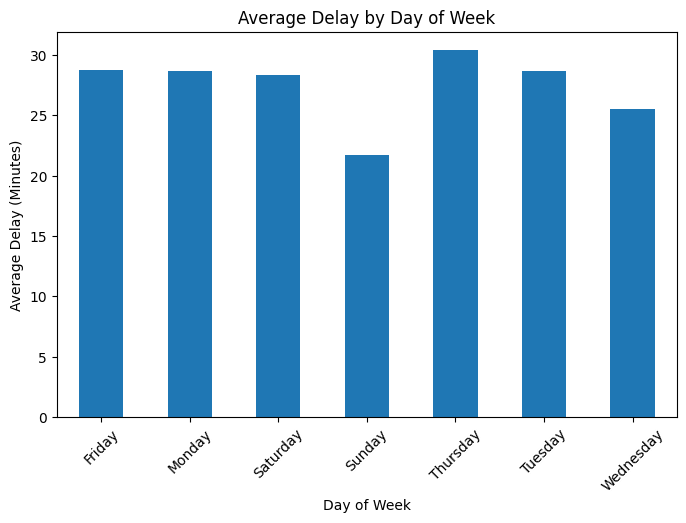

In [ ]:
plt.figure(figsize=(8,5))

weekday_delay.plot(kind="bar")

plt.title("Average Delay by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Delay (Minutes)")
plt.xticks(rotation=45)

plt.show()

### Delay Performance by Airline

This chart compares average flight delays across airlines to understand operational performance differences.

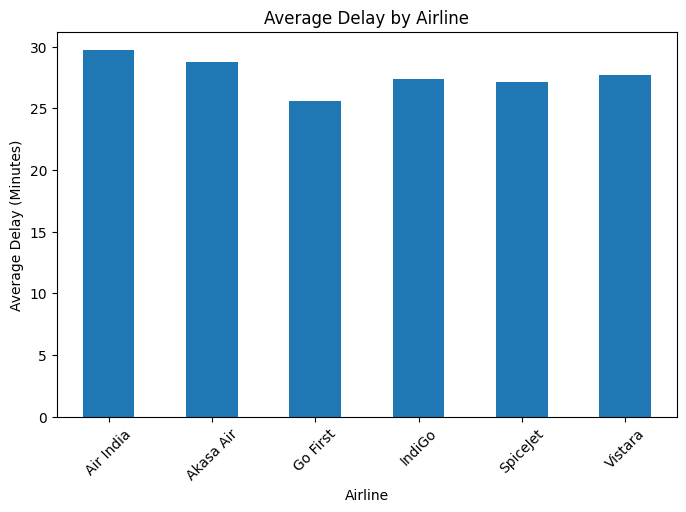

In [ ]:
plt.figure(figsize=(8,5))

airline_delay.plot(kind="bar")

plt.title("Average Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Delay (Minutes)")
plt.xticks(rotation=45)

plt.show()

### Delay Category Distribution

This chart shows the distribution of flights based on delay severity.

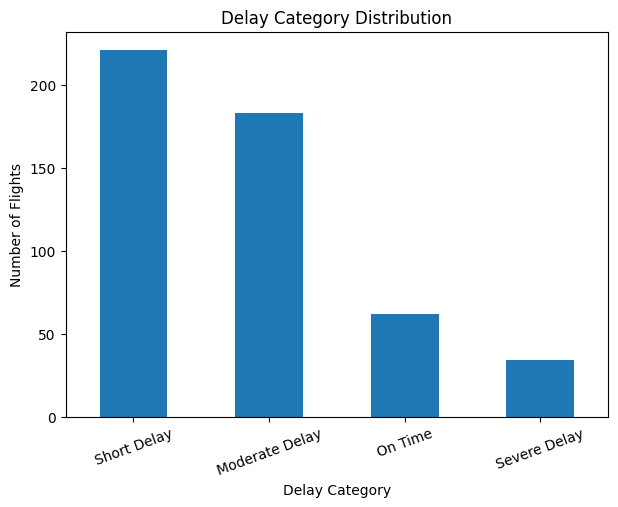

In [ ]:
plt.figure(figsize=(7,5))

delay_category_count.plot(
    kind="bar"
)

plt.title("Delay Category Distribution")
plt.xlabel("Delay Category")
plt.ylabel("Number of Flights")
plt.xticks(rotation=20)

plt.show()

In [ ]:
# For Flight Status Distribution

flight_status = flights["Flight_Status"].value_counts()

flight_status

,count
Flight_Status,
Delayed,339
On Time,148
Cancelled,13


### Flight Status Distribution

This chart shows the number of on-time, delayed, and cancelled flights in the dataset.

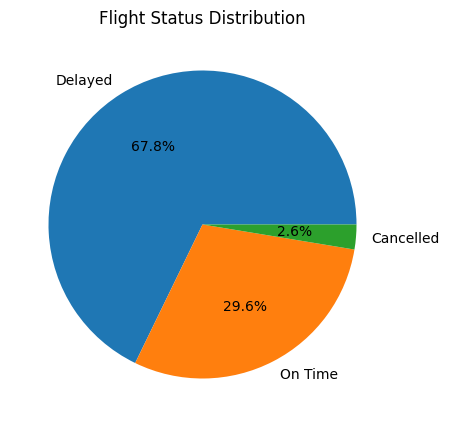

In [ ]:
plt.figure(figsize=(7,5))

flight_status.plot(kind="pie",autopct="%1.1f%%")

plt.title("Flight Status Distribution")

plt.ylabel("")

plt.show()

## SQL Basics for Flight Analysis

To understand how SQL can also be used for flight operations analysis, I added a few basic SQL queries to explore delay trends, flight performance, filtering, and grouping of data.

In [ ]:
import sqlite3

# Create database in memory
conn = sqlite3.connect(':memory:')

# Convert dataframe to SQL table
flights.to_sql(
    'flights',
    conn,
    index=False,
    if_exists='replace'
)

print("SQL table created successfully")

SQL table created successfully


### 1. View Flight Data

I used a simple query to view flight records from the dataset.

In [ ]:
query = """
SELECT * FROM flights
LIMIT 5;

"""

pd.read_sql(query, conn)

,Flight_ID,Airline,Origin_Airport,Destination_Airport,Scheduled_Departure,Actual_Departure,Delay_Minutes,Flight_Status,Flight_Duration_Minutes,Month,Day_of_Week,Departure_Hour,Is_Delayed,Delay_Category
0,FL1000,Go First,BOM,DEL,2025-04-04 21:00:00,2025-04-04 21:38:00,38,Delayed,122,Apr,Friday,21,1,Moderate Delay
1,FL1001,Go First,BOM,PNQ,2025-01-30 16:00:00,2025-01-30 16:24:00,24,Delayed,211,Jan,Thursday,16,1,Short Delay
2,FL1002,IndiGo,BOM,BLR,2025-03-21 09:00:00,2025-03-21 09:42:00,42,Delayed,189,Mar,Friday,9,1,Moderate Delay
3,FL1003,Akasa Air,HYD,PNQ,2025-05-24 04:00:00,2025-05-24 05:01:00,61,Delayed,116,May,Saturday,4,1,Severe Delay
4,FL1004,SpiceJet,DEL,AMD,2025-02-24 11:00:00,2025-02-24 11:22:00,22,Delayed,168,Feb,Monday,11,1,Short Delay


### 2. Average Delay by Airline

I used this query to check the average delay time for different airlines.

In [ ]:
query = """
SELECT Airline,
AVG(Delay_Minutes) AS Average_Delay
FROM flights
GROUP BY Airline;

"""

pd.read_sql(query, conn)

,Airline,Average_Delay
0,Air India,29.716049
1,Akasa Air,28.712871
2,Go First,25.573171
3,IndiGo,27.391892
4,SpiceJet,27.126437
5,Vistara,27.693333


### 3. Delay Trend by Day of Week

I used this query to understand how delays changed across weekdays.

In [ ]:
query = """
SELECT Day_of_Week,
AVG(Delay_Minutes) AS Average_Delay
FROM flights
GROUP BY Day_of_Week;
"""

pd.read_sql(query, conn)

,Day_of_Week,Average_Delay
0,Friday,28.744186
1,Monday,28.675325
2,Saturday,28.341463
3,Sunday,21.679245
4,Thursday,30.388889
5,Tuesday,28.671642
6,Wednesday,25.492063


### 4. Flights with High Delays

I used this query to filter flights with delays greater than 30 minutes.

In [ ]:
query = """
SELECT *
FROM flights
WHERE Delay_Minutes > 30;
"""

pd.read_sql(query, conn)

,Flight_ID,Airline,Origin_Airport,Destination_Airport,Scheduled_Departure,Actual_Departure,Delay_Minutes,Flight_Status,Flight_Duration_Minutes,Month,Day_of_Week,Departure_Hour,Is_Delayed,Delay_Category
0,FL1000,Go First,BOM,DEL,2025-04-04 21:00:00,2025-04-04 21:38:00,38,Delayed,122,Apr,Friday,21,1,Moderate Delay
1,FL1002,IndiGo,BOM,BLR,2025-03-21 09:00:00,2025-03-21 09:42:00,42,Delayed,189,Mar,Friday,9,1,Moderate Delay
2,FL1003,Akasa Air,HYD,PNQ,2025-05-24 04:00:00,2025-05-24 05:01:00,61,Delayed,116,May,Saturday,4,1,Severe Delay
3,FL1006,IndiGo,CCU,AMD,2025-04-28 09:00:00,2025-04-28 10:02:00,62,Delayed,214,Apr,Monday,9,1,Severe Delay
4,FL1007,IndiGo,AMD,MAA,2025-02-12 14:00:00,2025-02-12 14:44:00,44,Delayed,156,Feb,Wednesday,14,1,Moderate Delay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,FL1488,Air India,AMD,MAA,2025-06-19 01:00:00,2025-06-19 02:05:00,65,Delayed,200,Jun,Thursday,1,1,Severe Delay
213,FL1489,Akasa Air,BOM,HYD,2025-05-06 05:00:00,2025-05-06 05:47:00,47,Delayed,198,May,Tuesday,5,1,Moderate Delay
214,FL1491,Go First,HYD,BLR,2025-01-12 00:00:00,2025-01-12 01:00:00,60,Delayed,175,Jan,Sunday,0,1,Moderate Delay
215,FL1494,Air India,HYD,AMD,2025-01-21 06:00:00,2025-01-21 07:01:00,61,Delayed,205,Jan,Tuesday,6,1,Severe Delay


### 5. Flight Status Summary

I used this query to count flights based on flight status.

In [ ]:
query = """
SELECT Flight_Status,
COUNT(*) AS Total_Flights
FROM flights
GROUP BY Flight_Status;
"""

pd.read_sql(query, conn)

,Flight_Status,Total_Flights
0,Cancelled,13
1,Delayed,339
2,On Time,148


### SQL UseCase

I used these basic SQL queries to better understand filtering, grouping, aggregation, and reporting in flight operations data.

## Business Insights

After analyzing the data, I observed a few patterns in flight delays and overall flight performance.

### Key Insights

1. I found that flight delays were different across weekdays, and some days had higher delays than others.

2. I observed differences in average delay time across airlines, showing changes in flight performance.

3. Most flights had short or medium delays, while long delays happened less often.

4. I noticed a mix of on-time, delayed, and cancelled flights in the dataset, showing different operational situations.

5. Through this analysis, I understood how delay tracking can help monitor flight performance and operations.

## Conclusion

In this project, I used Python (Pandas) to analyze flight delays and flight performance. I worked on data cleaning, delay categories, KPI analysis, trend analysis, charts, and basic SQL queries to better understand flight operations data.